# Lab 2: Deep Q-Network (DQN)


Import

In [36]:
import random
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

Key differences from the TensorFlow version:
- `torch.nn` replaces `tensorflow.keras.layers`
- `collections.deque` is used for the replay buffer
- No external RL library needed - everything is implemented from scratch

Select and Inspect the environment

In [37]:
ENV_NAME = 'CartPole-v1'
env = gym.make(ENV_NAME, render_mode='rgb_array')
print(f'Environment:{ENV_NAME}')
print(f'Observation space: {env.observation_space}')
print(f'shape: {env.observation_space.shape}')
print(f'Action space: {env.action_space}')
print(f'N actions:{env.action_space.n}')

# Gymnasium API: reset returns (obs, info)
obs, info = env.reset(seed=42)
print(f'Initial obs shape:{obs.shape}')

Environment:CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
shape: (4,)
Action space: Discrete(2)
N actions:2
Initial obs shape:(4,)


In Gymnasium, `env.reset()` returns a tuple (observation, info) - not just the observation as in the old Gym. Always unpack both values: obs, info = env.reset()

Define state and action space sizes

In [38]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.np_random
print(f'State size: {state_size}')
print(f'Action size: {action_size}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

State size: 4
Action size: Generator(PCG64)
Using device: cpu


Build the Q-Network in Pytorch

In [39]:
action_size = env.action_space.n
print(f"Action size: {action_size}")

class QNetwork(nn.Module):
    """
    Fully-connected Q-network
    """
    def __init__(self, state_size, action_size, hidden_units=64, n_hidden=2):
        super().__init__()
        layers = [nn.Linear(state_size, hidden_units), nn.ReLU()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.ReLU()]
        layers.append(nn.Linear(hidden_units, action_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Instantiate online and target networks
online_net = QNetwork(state_size, action_size).to(device)
target_net = QNetwork(state_size, action_size).to(device)
target_net.load_state_dict(online_net.state_dict())
print(online_net)


Action size: 2
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


Implementation of the Replay buffer

In [40]:
class ReplayBuffer:
    """
    Fixed sized circular buffer storing (s,a,r,s',done) transitions
    """
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device)
        )
        
    def __len__(self):
        return len(self.buffer)
    
    
memory = ReplayBuffer(capacity=50000)

Defining Hyperparameters and optimizer

In [41]:
LEARNING_RATE = 1e-3
GAMMA = 0.99
BATCH_SIZE = 64
WARMUP_STEPS = 1000  # steps before trainig begins
TARGET_UPDATE_FREQ = 1000  # hard update every N steps
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995  # decay rate for epsilon per episode
MAX_EPISODES = 500
optimizer = optim.Adam(online_net.parameters(), lr=LEARNING_RATE)

Implementing the training step

In [42]:
def train_step():
    if len(memory) < BATCH_SIZE:
        return None
    
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)
    # Current Q-values for the taken actions
    q_values = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    # Target Q-values using the bellman equation
    with torch.no_grad():
        # double dqn: online net selects action, target net evaluates it
        next_actions = online_net(next_states).argmax(dim=1)
        next_q = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        target_q = rewards + (1 - dones) * GAMMA * next_q
    loss = F.mse_loss(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10)
    optimizer.step()
    return loss.item()

The training step above implements Double DQN by default: the online network selects the best next action but the target network evaluates its q-value. this reduces overestimation bias with no extra computational cost

Main training loop

In [43]:
epsilon = EPSILON_START
total_steps = 0
episode_rewards = []

for episode in range(MAX_EPISODES):
    obs, info = env.reset()
    episode_reward = 0
    done = False
    while not done:
        if total_steps < WARMUP_STEPS or random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            with torch.no_grad():
                action = online_net(state_t).argmax().item()
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        memory.push(obs, action, reward, next_obs, done)
        obs = next_obs
        episode_reward += reward
        total_steps += 1
        # learn
        if total_steps >= WARMUP_STEPS:
            train_step()
        # update target network
        if total_steps % TARGET_UPDATE_FREQ == 0:
            target_net.load_state_dict(online_net.state_dict())
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(episode_reward)
    if (episode + 1)%20 == 0:
        mean_r = np.mean(episode_rewards[-20:])
        print(f'Episode {episode+1}, Reward: {episode_reward}, Mean(20): {mean_r:.2f}, Epsilon: {epsilon:.3f}')
        
env.close()
    

Episode 20, Reward: 16.0, Mean(20): 19.45, Epsilon: 0.905
Episode 40, Reward: 40.0, Mean(20): 20.90, Epsilon: 0.818
Episode 60, Reward: 10.0, Mean(20): 22.25, Epsilon: 0.740
Episode 80, Reward: 12.0, Mean(20): 16.80, Epsilon: 0.670
Episode 100, Reward: 9.0, Mean(20): 16.25, Epsilon: 0.606
Episode 120, Reward: 14.0, Mean(20): 15.85, Epsilon: 0.548
Episode 140, Reward: 14.0, Mean(20): 14.50, Epsilon: 0.496
Episode 160, Reward: 11.0, Mean(20): 13.35, Epsilon: 0.448
Episode 180, Reward: 11.0, Mean(20): 16.90, Epsilon: 0.406
Episode 200, Reward: 23.0, Mean(20): 24.45, Epsilon: 0.367
Episode 220, Reward: 98.0, Mean(20): 29.90, Epsilon: 0.332
Episode 240, Reward: 105.0, Mean(20): 71.25, Epsilon: 0.300
Episode 260, Reward: 16.0, Mean(20): 123.90, Epsilon: 0.272
Episode 280, Reward: 18.0, Mean(20): 160.30, Epsilon: 0.246
Episode 300, Reward: 14.0, Mean(20): 99.90, Epsilon: 0.222
Episode 320, Reward: 223.0, Mean(20): 120.20, Epsilon: 0.201
Episode 340, Reward: 131.0, Mean(20): 173.05, Epsilon: 0

visualizing the training reward curve

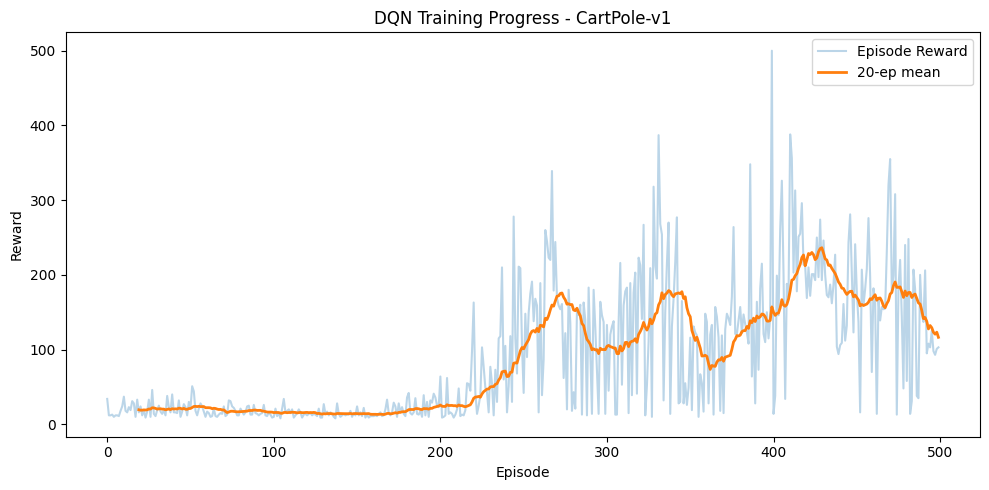

In [44]:
window = 20
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, label='Episode Reward')
plt.plot(range(window-1, len(episode_rewards)), smoothed, linewidth=2, label=f'{window}-ep mean')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title(f'DQN Training Progress - {ENV_NAME}')
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/training_curve_{ENV_NAME}.png')
plt.show()

test the trained agent

In [45]:
test_env = gym.make(ENV_NAME, render_mode='human')
test_rewards = []
online_net.eval()
for episode in range(10):
    obs, info = test_env.reset()
    total_r = 0
    done = False
    while not done:
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            action = online_net(state_t).argmax().item()
        obs, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        total_r += reward
    test_rewards.append(total_r)
    print(f'Test Episode {episode+1}, Reward: {total_r:.1f}')
    
print(f'\nMean reward: {np.mean(test_rewards):.2f}')
print(f'Std reward: {np.std(test_rewards):.2f}')
print(f'Min reward: {np.min(test_rewards):.1f}')
print(f'Max reward: {np.max(test_rewards):.1f}')
test_env.close()

Test Episode 1, Reward: 95.0
Test Episode 2, Reward: 98.0
Test Episode 3, Reward: 92.0
Test Episode 4, Reward: 100.0
Test Episode 5, Reward: 98.0
Test Episode 6, Reward: 92.0
Test Episode 7, Reward: 93.0
Test Episode 8, Reward: 98.0
Test Episode 9, Reward: 92.0
Test Episode 10, Reward: 91.0

Mean reward: 94.90
Std reward: 3.14
Min reward: 91.0
Max reward: 100.0


save and reload the agent

In [46]:
torch.save(online_net.state_dict(), f'models/dqn_{ENV_NAME}_weights.pth')
print(f'Weights saved to models/dqn_{ENV_NAME}_weights.pth')


Weights saved to models/dqn_CartPole-v1_weights.pth


reloading weights

In [47]:
model2 = QNetwork(state_size, action_size).to(device)
model2.load_state_dict(torch.load(f'models/dqn_{ENV_NAME}_weights.pth'))
model2.eval()

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

let's repeat this for all environments

In [48]:
ENV_NAME2 = 'MountainCar-v0'
env2 = gym.make(ENV_NAME2, render_mode='rgb_array')
print(f'Environment:{ENV_NAME2}')
print(f'Observation space: {env2.observation_space}')
print(f'shape: {env2.observation_space.shape}')
print(f'Action space: {env2.action_space}')
print(f'N actions:{env2.action_space.n}')

# Gymnasium API: reset returns (obs, info)
obs, info = env2.reset(seed=42)
print(f'Initial obs shape:{obs.shape}')

Environment:MountainCar-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
shape: (2,)
Action space: Discrete(3)
N actions:3
Initial obs shape:(2,)


In [49]:
state_size = env2.observation_space.shape[0]
action_size = env2.action_space.n
print(f'State size: {state_size}')
print(f'Action size: {action_size}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

State size: 2
Action size: 3
Using device: cpu


In [50]:
online_net2 = QNetwork(state_size, action_size).to(device)
target_net2 = QNetwork(state_size, action_size).to(device)
target_net2.load_state_dict(online_net2.state_dict())
target_net2.eval()
print(online_net2)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [51]:
epsilon = EPSILON_START
total_steps = 0
episode_rewards = []
for episode in range(MAX_EPISODES):
    obs, info = env2.reset()
    episode_reward = 0
    done = False
    while not done:
        if total_steps < WARMUP_STEPS or random.random() < epsilon:
            action = env2.action_space.sample()
        else:
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            with torch.no_grad():
                action = online_net2(state_t).argmax().item()
        next_obs, reward, terminated, truncated, info = env2.step(action)
        done = terminated or truncated
        obs = next_obs
        episode_reward += reward
        total_steps += 1
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(episode_reward)
    if (episode + 1)%20 == 0:
        mean_r = np.mean(episode_rewards[-20:])
        print(f'Episode {episode+1}, Reward: {episode_reward}, Mean(20): {mean_r:.2f}, Epsilon: {epsilon:.3f}')
        
env2.close()

Episode 20, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.905
Episode 40, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.818
Episode 60, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.740
Episode 80, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.670
Episode 100, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.606
Episode 120, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.548
Episode 140, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.496
Episode 160, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.448
Episode 180, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.406
Episode 200, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.367
Episode 220, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.332
Episode 240, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.300
Episode 260, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.272
Episode 280, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.246
Episode 300, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.222
Episode 320, Reward: -200.0, Mean(20): -200.00, Epsilon: 0.

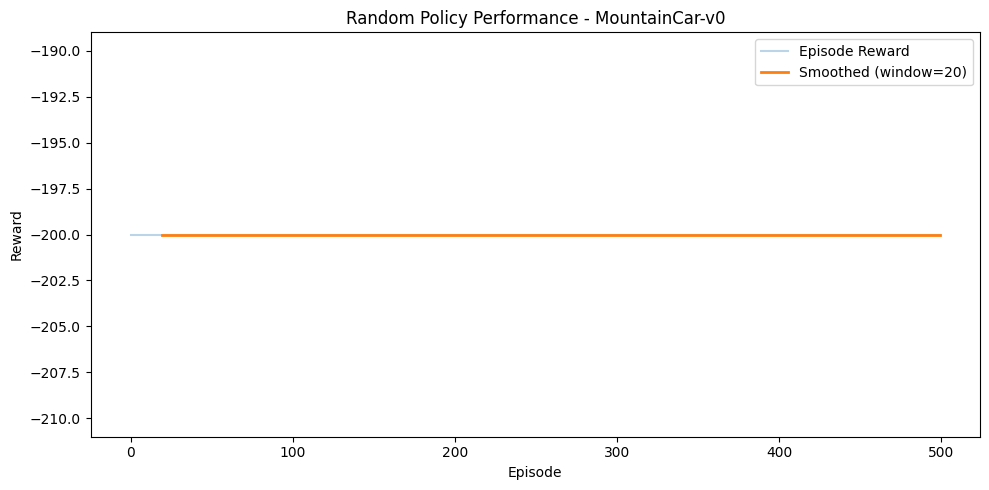

In [52]:
window = 20
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, label='Episode Reward')
plt.plot(range(window-1, len(episode_rewards)), smoothed, linewidth=2, label='Smoothed (window=20)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title(f'Random Policy Performance - {ENV_NAME2}')
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/random_policy_{ENV_NAME2}.png')
plt.show()

In [53]:
test_env2 = gym.make(ENV_NAME2, render_mode='human')
test_rewards = []
online_net2.eval()
for episode in range(10):
    obs, info = test_env2.reset()
    total_r = 0
    done = False
    while not done:
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            action = online_net2(state_t).argmax().item()
        obs, reward, terminated, truncated, info = test_env2.step(action)
        done = terminated or truncated
        total_r += reward
    test_rewards.append(total_r)
    print(f'Test Episode {episode+1}, Reward: {total_r:.1f}')
    
print(f'\nMean reward: {np.mean(test_rewards):.2f}')
print(f'Std reward: {np.std(test_rewards):.2f}')
print(f'Min reward: {np.min(test_rewards):.1f}')
print(f'Max reward: {np.max(test_rewards):.1f}')
test_env2.close()

Test Episode 1, Reward: -200.0
Test Episode 2, Reward: -200.0
Test Episode 3, Reward: -200.0
Test Episode 4, Reward: -200.0
Test Episode 5, Reward: -200.0
Test Episode 6, Reward: -200.0
Test Episode 7, Reward: -200.0
Test Episode 8, Reward: -200.0
Test Episode 9, Reward: -200.0
Test Episode 10, Reward: -200.0

Mean reward: -200.00
Std reward: 0.00
Min reward: -200.0
Max reward: -200.0


In [54]:
torch.save(online_net.state_dict(), f'models/dqn_{ENV_NAME2}_weights.pth')
print(f'Weights saved to models/dqn_{ENV_NAME2}_weights.pth')

Weights saved to models/dqn_MountainCar-v0_weights.pth
